# Neural Network

<span style="color:red;">
Ce notebook a été exécuté sur Google Colab avec un GPU A100 et a été configuré pour ce GPU. S’il est exécuté sur une autre machine, il peut ne pas fonctionner.
</span>


In [3]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    AutoConfig
)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from torch import nn

In [34]:
ds = load_dataset("google/code_x_glue_cc_clone_detection_big_clone_bench")

## Configuration pour la carte graphique A100 (google colab)


In [35]:
# --- 2. CONFIGURATION (Pour ta A100) ---
MODEL_NAME = "microsoft/unixcoder-base"
MAX_LEN = 512
BATCH_SIZE = 32     # Augmenté pour la A100 (essayez 48 si ça passe)
NUM_EPOCHS = 3

## Préparation des données

In [36]:
ds = ds.map(lambda x: {"label": int(x["label"])})

train_labels = np.array(ds["train"]["label"])
class_counts = np.bincount(train_labels)
total_samples = len(train_labels)

In [37]:
class_weights = torch.tensor(total_samples / (2.0 * class_counts), dtype=torch.float)

print(f"Répartition (Train): 0 (Faux): {class_counts[0]}, 1 (Vrai): {class_counts[1]}")
print(f"Poids calculés: {class_weights}")

Répartition (Train): 0 (Faux): 450166, 1 (Vrai): 450862
Poids calculés: tensor([1.0008, 0.9992])


In [38]:
# --- 4. TOKENIZATION ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess_function(examples):
    return tokenizer(
        examples["func1"],
        examples["func2"],
        truncation=True,
        max_length=MAX_LEN,
    )

encoded_ds = ds.map(preprocess_function, batched=True, num_proc=8)
encoded_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

train_ds = encoded_ds["train"]
eval_ds = encoded_ds["validation"]
test_ds = encoded_ds["test"]

Map (num_proc=8):   0%|          | 0/901028 [00:00<?, ? examples/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c9294c572e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c9294c572e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Map (num_proc=8):   0%|          | 0/415416 [00:00<?, ? examples/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c9294c572e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c9294c572e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Map (num_proc=8):   0%|          | 0/415416 [00:00<?, ? examples/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c9294c572e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c9294c572e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

## Entrainement

In [39]:
# --- 5. CUSTOM TRAINER CORRIGÉ (V2) ---
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # 1. On extrait les labels
        labels = inputs.get("labels")

        # 2. On crée un dictionnaire d'inputs SANS les labels pour le forward pass
        forward_inputs = {k: v for k, v in inputs.items() if k != "labels"}

        # 3. Forward pass
        outputs = model(**forward_inputs)
        logits = outputs.get("logits")

        # 4. Calcul de la Loss pondérée
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device))

        # --- CORRECTION ICI ---
        # On ajoute .long() pour convertir les labels (Bool) en Entiers (0 ou 1)
        # Sinon PyTorch plante sur GPU avec l'erreur "not implemented for 'Bool'"
        loss = loss_fct(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1).long()
        )

        return (loss, outputs) if return_outputs else loss

In [40]:
# --- 6. CONFIGURATION EXPLICITE ---
config = AutoConfig.from_pretrained(MODEL_NAME, num_labels=2)

# Ajoutez cette ligne pour forcer le mode Classification Simple
config.problem_type = "single_label_classification"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions)
    prec = precision_score(labels, predictions)
    rec = recall_score(labels, predictions)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": prec,
        "recall": rec
    }

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/unixcoder-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [41]:
# --- 7. ARGUMENTS D'ENTRAÎNEMENT OPTIMISÉS A100 ---
training_args = TrainingArguments(
    output_dir="./unixcoder_weighted_results",
    learning_rate=2e-5,

    # Augmentation Batch Size (A100 supporte largement 64, peut-être 96)
    per_device_train_batch_size=64,
    per_device_eval_batch_size=128, # L'eval consomme moins de mémoire, on double

    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    fp16=True,
    dataloader_num_workers=4,

    # OPTIMISATION CRUCIALE
    group_by_length=True, # Groupe les séquences de taille similaire (boost vitesse)

    logging_steps=100,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

In [42]:
# --- 8. LANCEMENT ---
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    tokenizer=tokenizer,
    # Le data collator va maintenant faire le padding dynamiquement à chaque batch
    data_collator=DataCollatorWithPadding(tokenizer, pad_to_multiple_of=8),
    compute_metrics=compute_metrics,
)

print("Démarrage de l'entraînement TURBO sur A100...")
trainer.train()

/tmp/ipython-input-2096964542.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


Démarrage de l'entraînement TURBO sur A100...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.005500,0.137838,0.979714,0.923590,0.902246,0.945969
2,0.001800,0.172416,0.981344,0.929053,0.915988,0.942495
3,0.000500,0.192466,0.981043,0.928442,0.908845,0.948903


TrainOutput(global_step=42237, training_loss=0.0079350724851955, metrics={'train_runtime': 8183.3738, 'train_samples_per_second': 330.314, 'train_steps_per_second': 5.161, 'total_flos': 6.185516938227725e+17, 'train_loss': 0.0079350724851955, 'epoch': 3.0})

## Analyse des résultats

In [43]:
predictions_output = trainer.predict(test_ds)

# Les 'logits' sont les scores bruts avant décision (taille: [N_samples, 2])
logits = predictions_output.predictions

# On prend l'index du score le plus élevé (0 ou 1) pour avoir la classe prédite
preds = np.argmax(logits, axis=-1)
labels = predictions_output.label_ids

# --- 2. CALCUL DES MÉTRIQUES ---
acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds)
prec = precision_score(labels, preds)
rec = recall_score(labels, preds)

print("\n" + "="*30)
print(" RÉSULTATS DÉTAILLÉS ")
print("="*30)
print(f"Accuracy    : {acc:.4f} (Attention, trompeur si déséquilibré)")
print(f"Precision   : {prec:.4f} (Qualité : quand il dit 'C'est un clone', a-t-il raison ?)")
print(f"Recall      : {rec:.4f} (Quantité : combien de vrais clones a-t-il trouvés ?)")
print(f"F1 Score    : {f1:.4f} (Moyenne harmonique, le juge de paix)")
print("-" * 30)


 RÉSULTATS DÉTAILLÉS 
Accuracy    : 0.9839 (Attention, trompeur si déséquilibré)
Precision   : 0.9487 (Qualité : quand il dit 'C'est un clone', a-t-il raison ?)
Recall      : 0.9326 (Quantité : combien de vrais clones a-t-il trouvés ?)
F1 Score    : 0.9406 (Moyenne harmonique, le juge de paix)
------------------------------


On constate que nos métrique sont toutes trés bonne, le F1 score est de 0.94 ce qui veux dire que le déséquillibre de nos classes de base à été vaincu. 

In [44]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

print("\nRapport de classification par classe :")
print(classification_report(labels, preds, target_names=["Non-Clone (0)", "Clone (1)"]))


Rapport de classification par classe :
               precision    recall  f1-score   support

Non-Clone (0)       0.99      0.99      0.99    358596
    Clone (1)       0.95      0.93      0.94     56820

     accuracy                           0.98    415416
    macro avg       0.97      0.96      0.97    415416
 weighted avg       0.98      0.98      0.98    415416



/tmp/ipython-input-4194326697.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Catégorie', y='Nombre', data=df_cm, palette=colors)


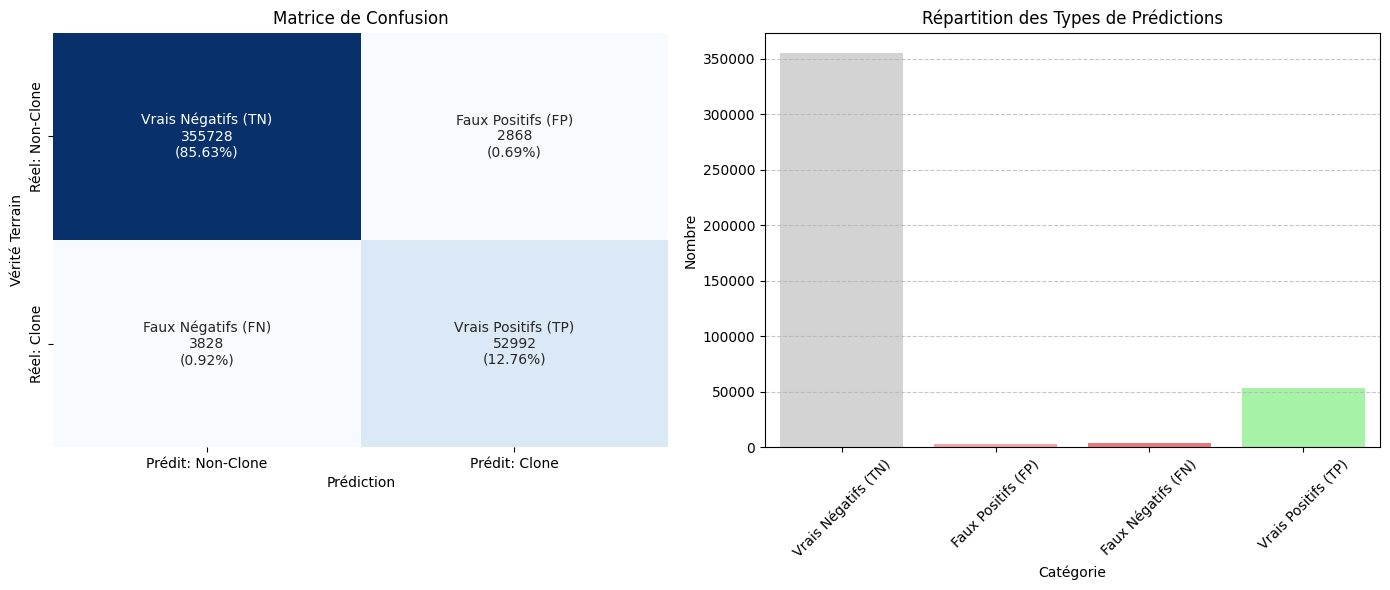

In [50]:
import pandas as pd

# 2. Préparation des labels pour le graphique
group_names = ['Vrais Négatifs (TN)', 'Faux Positifs (FP)', 'Faux Négatifs (FN)', 'Vrais Positifs (TP)']
group_counts = cm.flatten()
group_percentages = ["{0:.2%}".format(value) for value in group_counts/np.sum(cm)]
box_labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
box_labels = np.asarray(box_labels).reshape(2,2)

# 3. Création de la figure (2 graphiques côte à côte)
plt.figure(figsize=(14, 6))

# --- Graphique A : Matrice de Confusion (Heatmap) ---
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=box_labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=["Prédit: Non-Clone", "Prédit: Clone"],
            yticklabels=["Réel: Non-Clone", "Réel: Clone"])
plt.title('Matrice de Confusion')
plt.ylabel('Vérité Terrain')
plt.xlabel('Prédiction')

# --- Graphique B : Diagramme en Barres (Comparaison directe) ---
plt.subplot(1, 2, 2)
df_cm = pd.DataFrame({'Catégorie': group_names, 'Nombre': group_counts})
colors = ['#d3d3d3', '#ff9999', '#ff6666', '#99ff99'] # Gris, Rouge clair, Rouge foncé, Vert
sns.barplot(x='Catégorie', y='Nombre', data=df_cm, palette=colors)
plt.title('Répartition des Types de Prédictions')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Ces résultats graphiques confirment l'excellente performance du modèle qui gère parfaitement le fort déséquilibre des classes, identifiant correctement la quasi-totalité des clones (barre verte) sans se laisser noyer par la classe majoritaire. Avec moins de 1 % d'erreurs cumulées (Faux Positifs et Négatifs), la fiabilité de la détection est clairement établie et le modèle est prêt pour un usage réel.